In [1]:
# Erstmal alle notwendigen Bibliotheken importieren
import numpy as np
import matplotlib.pyplot as plt
import uncertainties.unumpy as unp
from uncertainties import ufloat

In [2]:
# Daten aus der CSV-Datei laden
BI, BdI, BU, BdU = np.loadtxt('Messdaten_Batterie.csv', delimiter=';', unpack=True, skiprows=1)
QI, QdI, QU, QdU = np.loadtxt('Messdaten_Quelle.csv', delimiter=';', unpack=True, skiprows=1)

In [3]:
# Nun wandeln wir unsere Arrays in Unumpy-Arrays um
B_I = unp.uarray(BI, BdI)
B_U = unp.uarray(BU, BdU) 
Q_I = unp.uarray(QI, QdI)
Q_U = unp.uarray(QU, QdU)

<ErrorbarContainer object of 3 artists>

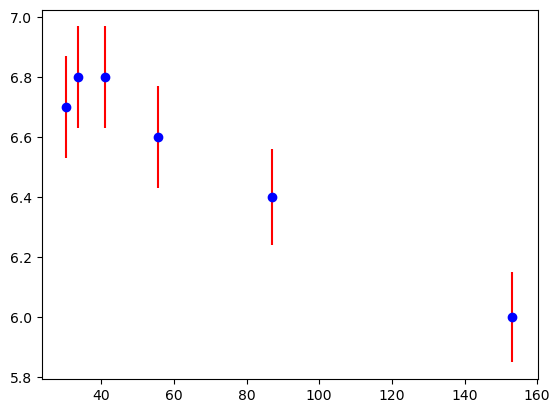

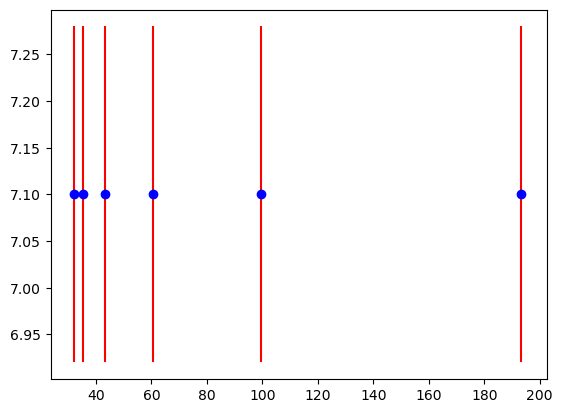

In [4]:
# Da diese Grafik nicht in einen Bericht muss, lassen wir Titel und Achsenbeschriftungen weg
plt.errorbar(BI, BU, xerr=BdI, yerr=BdU, fmt='o', label='Messwerte', color='blue', ecolor='red')
plt.figure()
plt.errorbar(QI, QU, xerr=QdI, yerr=QdU, fmt='o', label='Messwerte', color='blue', ecolor='red')

In [5]:
# Lineare Regression und Minimale/ Maximale Steigung



# Zunächst die Regression
B_K = np.polyfit(BI, BU, 1, cov=False)
Q_K = np.polyfit(QI, QU, 1, cov=False)



# Nun die Unsicherheiten der Steigungen

#Für die Minmale Steigung verwenden wir die obere Schranke des größten Messpunktes und die untere Schranke des kleinsten Messpunktes
B_K_Min = np.polyfit([BI[2]+BdI[2], BI[5]-BdI[5]], [BU[2]+BdU[2], BU[5]-BdU[5]], 1, cov=False)
Q_K_Min = np.polyfit([QI[0]+QdI[0], QI[5]-QdI[5]], [QU[0]+QdU[0], QU[5]-QdU[5]], 1, cov=False)

# Für die Maximale Steigung verwenden wir die untere Schranke des größten Messpunktes und die obere Schranke des kleinsten Messpunktes
B_K_Max = np.polyfit([BI[0]-BdI[0], BI[5]+BdI[5]], [BU[0]-BdU[0], BU[5]+BdU[5]], 1, cov=False)
Q_K_Max = np.polyfit([QI[0]-QdI[0], QI[5]+QdI[5]], [QU[0]-QdU[0], QU[5]+QdU[5]], 1, cov=False)

Batterie: Quellspannung = 7.0+/-0.4 V, Innenwiederstand = -0.006+/-0.004 Ω


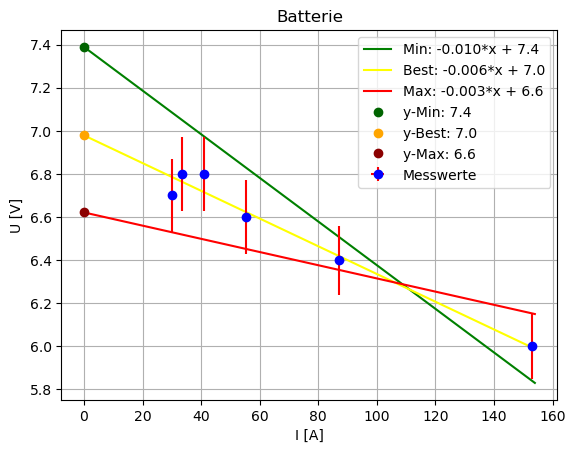

In [6]:
# x-Achsen für die Plots erstellen
Bx = np.linspace(0, BI[5]+BdI[5], 100)

# Plotten
plt.plot(Bx, B_K_Min[0] * Bx + B_K_Min[1], label=f'Min: {B_K_Min[0]:.3f}*x + {B_K_Min[1]:.1f}', color='green')
plt.plot(Bx, B_K[0] * Bx + B_K[1], label=f'Best: {B_K[0]:.3f}*x + {B_K[1]:.1f}', color='yellow')
plt.plot(Bx, B_K_Max[0] * Bx + B_K_Max[1], label=f'Max: {B_K_Max[0]:.3f}*x + {B_K_Max[1]:.1f}', color='red')
plt.errorbar(BI, BU, xerr=BdI, yerr=BdU, fmt='o', label='Messwerte', color='blue', ecolor='red')

# Nun brauchen wir noch den y-Achsenabschnitt
plt.plot([0], [B_K_Min[1]], 'o', label=f'y-Min: {B_K_Min[1]:.1f}', color='darkgreen')
plt.plot([0], [B_K[1]], 'o', label=f'y-Best: {B_K[1]:.1f}', color='orange')
plt.plot([0], [B_K_Max[1]], 'o', label=f'y-Max: {B_K_Max[1]:.1f}', color='darkred')

# Und verschönern die Grafik für den Bericht
plt.legend()
plt.ylabel('U [V]')
plt.xlabel('I [A]')
plt.title('Batterie')
plt.grid()

# Nun wollen wir noch die Werte erhalten, ohne in der Grafik zu suchen
BUq = ufloat(B_K[1], max(abs(B_K_Max[1] - B_K[1]), abs(B_K_Min[1] - B_K[1])))
BRi = ufloat(B_K[0], max(abs(B_K_Max[0] - B_K[0]), abs(B_K_Min[0] - B_K[0])))
print(f'Batterie: Quellspannung = {BUq:.1f} V, Innenwiederstand = {BRi:.3f} Ω')

Spannungsquelle: Quellspannung = 7.1+/-0.3 V, Innenwiderstand = 0.0000+/-0.0023 Ω


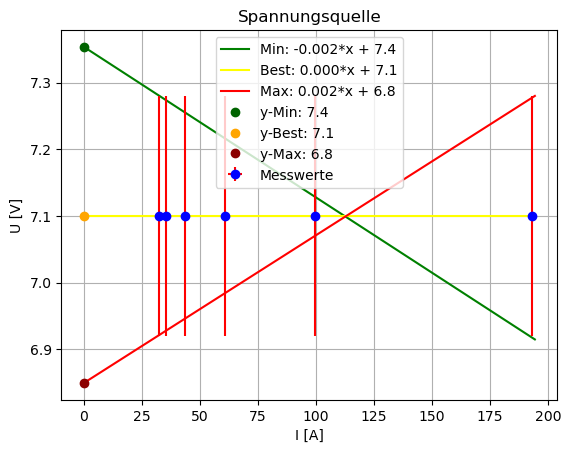

In [7]:
# Nun noch für die Spannungsquelle
Qx = np.linspace(0, QI[5]+QdI[5], 100)

# Plotten
plt.plot(Qx, Q_K_Min[0] * Qx + Q_K_Min[1], label=f'Min: {Q_K_Min[0]:.3f}*x + {Q_K_Min[1]:.1f}', color='green')
plt.plot(Qx, Q_K[0] * Qx + Q_K[1], label=f'Best: {Q_K[0]:.3f}*x + {Q_K[1]:.1f}', color='yellow')
plt.plot(Qx, Q_K_Max[0] * Qx + Q_K_Max[1], label=f'Max: {Q_K_Max[0]:.3f}*x + {Q_K_Max[1]:.1f}', color='red')
plt.errorbar(QI, QU, xerr=QdI, yerr=QdU, fmt='o', label='Messwerte', color='blue', ecolor='red')

# Nun brauchen wir noch den y-Achsenabschnitt
plt.plot([0], [Q_K_Min[1]], 'o', label=f'y-Min: {Q_K_Min[1]:.1f}', color='darkgreen')
plt.plot([0], [Q_K[1]], 'o', label=f'y-Best: {Q_K[1]:.1f}', color='orange')
plt.plot([0], [Q_K_Max[1]], 'o', label=f'y-Max: {Q_K_Max[1]:.1f}', color='darkred')

# Und verschönern die Grafik für den Bericht
plt.legend()
plt.ylabel('U [V]')
plt.xlabel('I [A]')
plt.title('Spannungsquelle')
plt.grid()

# Nun wollen wir noch die Werte erhalten, ohne in der Grafik zu suchen
QUq = ufloat(Q_K[1], max(abs(Q_K_Max[1] - Q_K[1]), abs(Q_K_Min[1] - Q_K[1])))
QRi = ufloat(Q_K[0], max(abs(Q_K_Max[0] - Q_K[0]), abs(Q_K_Min[0] - Q_K[0])))
print(f'Spannungsquelle: Quellspannung = {QUq:.1f} V, Innenwiderstand = {QRi:.4f} Ω')

In [8]:
# Da die Näherung mit ODR besser ist, werden wir nun diese Metode verwenden.

from scipy import odr

In [9]:
def L(beta, x):
    return beta[0] * x + beta[1]
model = odr.Model(L)
data_B = odr.RealData(BI, BU, sx=BdI, sy=BdU)
odr_obj_B = odr.ODR(data_B, model, beta0=[-0.01, 7])
odr_res_B = odr_obj_B.run()
beta_B = odr_res_B.beta
sd_B = odr_res_B.sd_beta
S_B = ufloat(beta_B[0], sd_B[0])
Y_B = ufloat(beta_B[1], sd_B[1])
print('Innerwiderstand Batterie:', S_B,'Ω   ', 'Quellspannung Batterie:', Y_B, 'V')

Innerwiderstand Batterie: -0.0064+/-0.0006 Ω    Quellspannung Batterie: 6.98+/-0.05 V


In [10]:
data_Q = odr.RealData(QI, QU, sx=QdI, sy=QdU)
odr_obj_Q = odr.ODR(data_Q, model, beta0=[0, 7.1])
odr_res_Q = odr_obj_Q.run()
beta_Q = odr_res_Q.beta
sd_Q = odr_res_Q.sd_beta
S_Q = ufloat(beta_Q[0], sd_Q[0])
Y_Q = ufloat(beta_Q[1], sd_Q[1])
print('Innerwiderstand Quelle:', S_Q, 'Ω   ', 'Quellspannung Quelle:', Y_Q, 'V')

Innerwiderstand Quelle: 0.0+/-0 Ω    Quellspannung Quelle: 7.1+/-0 V


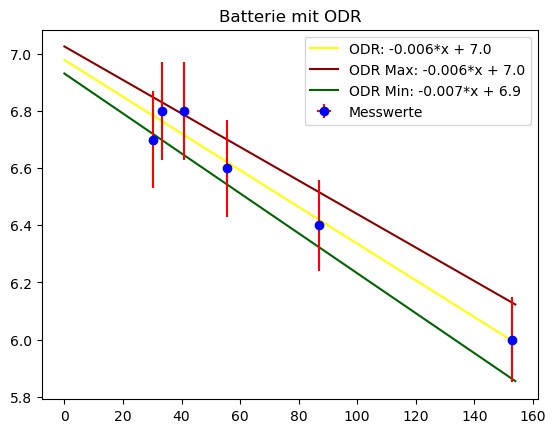

In [11]:
plt.plot(Bx, beta_B[0] * Bx + beta_B[1], label=f'ODR: {S_B.n:.3f}*x + {Y_B.n:.1f}', color='yellow')
plt.plot(Bx, (S_B.n + sd_B[0]) * Bx + (Y_B.n + sd_B[1]), label=f'ODR Max: {(S_B.n + sd_B[0]):.3f}*x + {(Y_B.n + sd_B[1]):.1f}', color='darkred')
plt.plot(Bx, (S_B.n - sd_B[0]) * Bx + (Y_B.n - sd_B[1]), label=f'ODR Min: {(S_B.n - sd_B[0]):.3f}*x + {(Y_B.n - sd_B[1]):.1f}', color='darkgreen')
plt.errorbar(BI, BU, xerr=BdI, yerr=BdU, fmt='o', label='Messwerte', color='blue', ecolor='red')
plt.title('Batterie mit ODR')
plt.legend()

Text(0.1, 0, 'Die Unsicherheiten sind so klein, dass alle Graphen zusammenfallen')

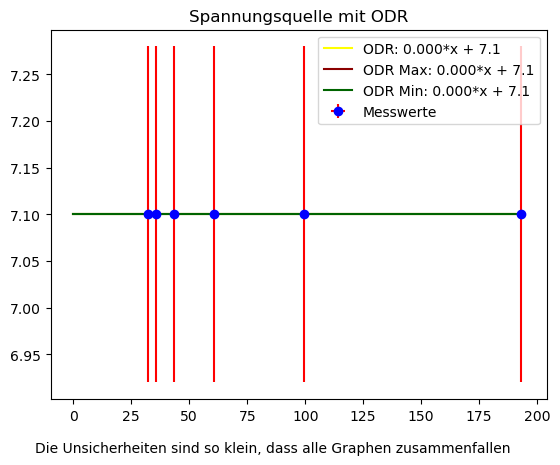

In [12]:
plt.plot(Qx, beta_Q[0] * Qx + beta_Q[1], label=f'ODR: {S_Q.n:.3f}*x + {Y_Q.n:.1f}', color='yellow')
plt.plot(Qx, (S_Q.n + sd_Q[0]) * Qx + (Y_Q.n + sd_Q[1]), label=f'ODR Max: {(S_Q.n + sd_Q[0]):.3f}*x + {(Y_Q.n + sd_Q[1]):.1f}', color='darkred')
plt.plot(Qx, (S_Q.n - sd_Q[0]) * Qx + (Y_Q.n - sd_Q[1]), label=f'ODR Min: {(S_Q.n - sd_Q[0]):.3f}*x + {(Y_Q.n - sd_Q[1]):.1f}', color='darkgreen')
plt.errorbar(QI, QU, xerr=QdI, yerr=QdU, fmt='o', label='Messwerte', color='blue', ecolor='red')
plt.title('Spannungsquelle mit ODR')
plt.legend()
plt.figtext(0.1, 0, 'Die Unsicherheiten sind so klein, dass alle Graphen zusammenfallen')